# Object Detection + Distance Estimation — ERIC Robotics ML Intern
**Author:** Satyam Shinde

End-to-end pipeline:
1. Setup + GPU check
2. Mount Drive (persistence)
3. Get dataset (Roboflow)
4. Drop in project code
5. Train YOLOv8
6. Inference + distance annotation
7. Export ONNX + INT8 quantize
8. Benchmark FPS
9. Download results

**BEFORE RUNNING:** Runtime → Change runtime type → **T4 GPU** → Save

## 1. GPU sanity check

In [13]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


Should show Tesla T4 (16GB). If 'command not found' → enable GPU runtime first.

## 2. Mount Google Drive (so weights survive session crashes)

In [14]:
from google.colab import drive
drive.mount('/content/drive')

# Project lives here in your Drive — outputs persist
import os
PROJECT_DIR = '/content/drive/MyDrive/eric_robotics_assignment'
os.makedirs(PROJECT_DIR, exist_ok=True)
%cd {PROJECT_DIR}
!pwd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/eric_robotics_assignment
/content/drive/MyDrive/eric_robotics_assignment


## 3. Install dependencies
Colab has PyTorch + CUDA preinstalled. Just add the rest.

In [15]:
!pip install -q ultralytics onnx onnxruntime onnxslim roboflow pyyaml --upgrade

# Verify
import torch, ultralytics
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')
print('Ultralytics:', ultralytics.__version__)

PyTorch: 2.10.0+cpu
CUDA available: False
GPU: none
Ultralytics: 8.4.41


## 4. Get dataset from Roboflow Universe

**Steps to do FIRST in browser:**
1. Go to https://universe.roboflow.com/
2. Search `traffic cone barrier stop sign` or `road obstacles`
3. Pick a public dataset with cone + barrier + stop_sign classes (>500 images)
4. Click **Download Dataset** → format **YOLOv8** → **Show download code**
5. Copy the Python snippet → paste it into the cell below (replace the example)

In [16]:
# Download BDD100K dataset from Kaggle

!pip install -q kaggle

# Create kaggle folder
!mkdir -p ~/.kaggle

# Copy uploaded kaggle.json file
!cp kaggle.json ~/.kaggle/

# Permission
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d solesensei/solesensei_bdd100k

# Unzip dataset
!unzip -q solesensei_bdd100k.zip -d /content/bdd100k_data

# Show files
print("Dataset extracted successfully")
!ls bdd100k_data

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/solesensei/solesensei_bdd100k
License(s): other
solesensei_bdd100k.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/bdd100k_data/bdd100k/bdd100k/images/100k/test/cb2fe290-8786cd14.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset extracted successfully
bdd100k


In [17]:
# Check BDD100K extracted folders
!ls /content/bdd100k_data

bdd100k  bdd100k_labels_release  bdd100k_seg


Note the class names + indices. If they differ from `cone/barrier/stop_sign`, that's fine — we use Roboflow's yaml directly.

## 5. Project code — write all source files inline
Keeps everything self-contained in this notebook.

In [18]:
!mkdir -p src configs

In [19]:
%%writefile configs/camera.yaml
camera:
  focal_px: 800
  image_width: 1280
  image_height: 720

object_heights_m:
  cone: 0.71
  barrier: 1.00
  stop_sign: 0.75
  # add any extra class names from your roboflow dataset here

default_height_m: 0.5

Writing configs/camera.yaml


In [23]:
%%writefile src/distance.py
"""Distance estimation via pinhole camera model."""
from pathlib import Path
import yaml

class DistanceEstimator:
    def __init__(self, config_path='configs/camera.yaml'):
        with open(config_path, 'r') as f:
            cfg = yaml.safe_load(f)
        self.focal_px = cfg['camera']['focal_px']
        self.heights = cfg['object_heights_m']
        self.default_h = cfg['default_height_m']

    def estimate(self, class_name, bbox_height_px):
        if bbox_height_px <= 0:
            return -1.0
        real_h = self.heights.get(class_name, self.default_h)
        return float((real_h * self.focal_px) / bbox_height_px)

    def estimate_from_box(self, class_name, xyxy):
        x1, y1, x2, y2 = xyxy
        return self.estimate(class_name, y2 - y1)

Overwriting src/distance.py


## 6. Train YOLOv8n with transfer learning

In [31]:
from ultralytics import YOLO
import os




DATASET_ROOT = "/content/bdd100k_data"
# We will need to generate this YAML file in the next step
DATA_YAML = os.path.join(DATASET_ROOT, "bdd100k.yaml")

if not os.path.exists(DATA_YAML):
    print(f"[!] {DATA_YAML} not found. We must create a YOLO-compatible config first.")
else:
    print("Using YAML:", DATA_YAML)

# Load pretrained YOLOv8 nano model
model = YOLO("yolov8n.pt")


try:
    results = model.train(
        data=DATA_YAML,
        epochs=5, # Reduced for testing fix
        imgsz=640,
        batch=16,
        device='cpu', # CPU used as no GPU was detected earlier
        project="runs/train",
        name="eric_robotics_exp",
        exist_ok=True
    )
except Exception as e:
    print(f"\nCaught Expected Error: {e}")
    print("\nNEXT STEP: Run the label conversion script to generate the missing .yaml and .txt labels.")

[!] /content/bdd100k_data/bdd100k.yaml not found. We must create a YOLO-compatible config first.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bdd100k_data/bdd100k.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=er

In [30]:
# Check the labels directory structure
!ls -R /content/bdd100k_data/bdd100k_labels_release | head -n 20

/content/bdd100k_data/bdd100k_labels_release:
bdd100k

/content/bdd100k_data/bdd100k_labels_release/bdd100k:
labels

/content/bdd100k_data/bdd100k_labels_release/bdd100k/labels:
bdd100k_labels_images_train.json
bdd100k_labels_images_val.json


In [32]:
import json, os, yaml
from pathlib import Path
from tqdm import tqdm

def convert_bdd100k_to_yolo():
    # Paths based on previous 'ls' output
    root = '/content/bdd100k_data'
    img_dir = os.path.join(root, 'bdd100k/bdd100k/images/100k')
    label_json_dir = os.path.join(root, 'bdd100k_labels_release/bdd100k/labels')

    # Target classes for ERIC Robotics
    # Note: BDD100K class names might slightly differ; mapping common ones
    class_map = {'traffic sign': 0, 'traffic light': 1, 'car': 2, 'truck': 3, 'bus': 4}

    for split in ['train', 'val']:
        json_path = os.path.join(label_json_dir, f'bdd100k_labels_images_{split}.json')
        out_label_dir = os.path.join(root, 'labels', split)
        os.makedirs(out_label_dir, exist_ok=True)

        with open(json_path, 'r') as f:
            data = json.load(f)

        print(f'Converting {split} set...')
        for item in tqdm(data):
            img_name = item['name']
            label_path = os.path.join(out_label_dir, img_name.replace('.jpg', '.txt'))

            with open(label_path, 'w') as lf:
                if 'labels' in item:
                    for obj in item['labels']:
                        if obj.get('box2d') and obj['category'] in class_map:
                            cls_id = class_map[obj['category']]
                            box = obj['box2d']
                            # Convert to YOLO (normalized xywh)
                            dw, dh = 1/1280, 1/720 # BDD100K default res
                            x = (box['x1'] + box['x2']) / 2.0 * dw
                            y = (box['y1'] + box['y2']) / 2.0 * dh
                            w = (box['x2'] - box['x1']) * dw
                            h = (box['y2'] - box['y1']) * dh
                            lf.write(f'{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n')

    # Create YAML
    yaml_content = {
        'path': root,
        'train': 'bdd100k/bdd100k/images/100k/train',
        'val': 'bdd100k/bdd100k/images/100k/val',
        'names': {i: name for name, i in class_map.items()}
    }
    with open(os.path.join(root, 'bdd100k.yaml'), 'w') as f:
        yaml.dump(yaml_content, f)
    print('Labels converted and bdd100k.yaml created.')

convert_bdd100k_to_yolo()

Converting train set...


100%|██████████| 69863/69863 [00:10<00:00, 6752.00it/s]


Converting val set...


100%|██████████| 10000/10000 [00:01<00:00, 5883.30it/s]


Labels converted and bdd100k.yaml created.


In [34]:
from ultralytics import YOLO
import time
import glob

model = YOLO("yolov8n.pt")

images = glob.glob("/content/bdd100k_data/bdd100k/images/100k/val/*.jpg")[:50]

start = time.time()

for img in images:
    model.predict(source=img, device="cpu", verbose=False)

end = time.time()

fps = len(images) / (end - start)

print(f"Processed {len(images)} images")
print(f"FPS on CPU: {fps:.2f}")

Processed 0 images
FPS on CPU: 0.00


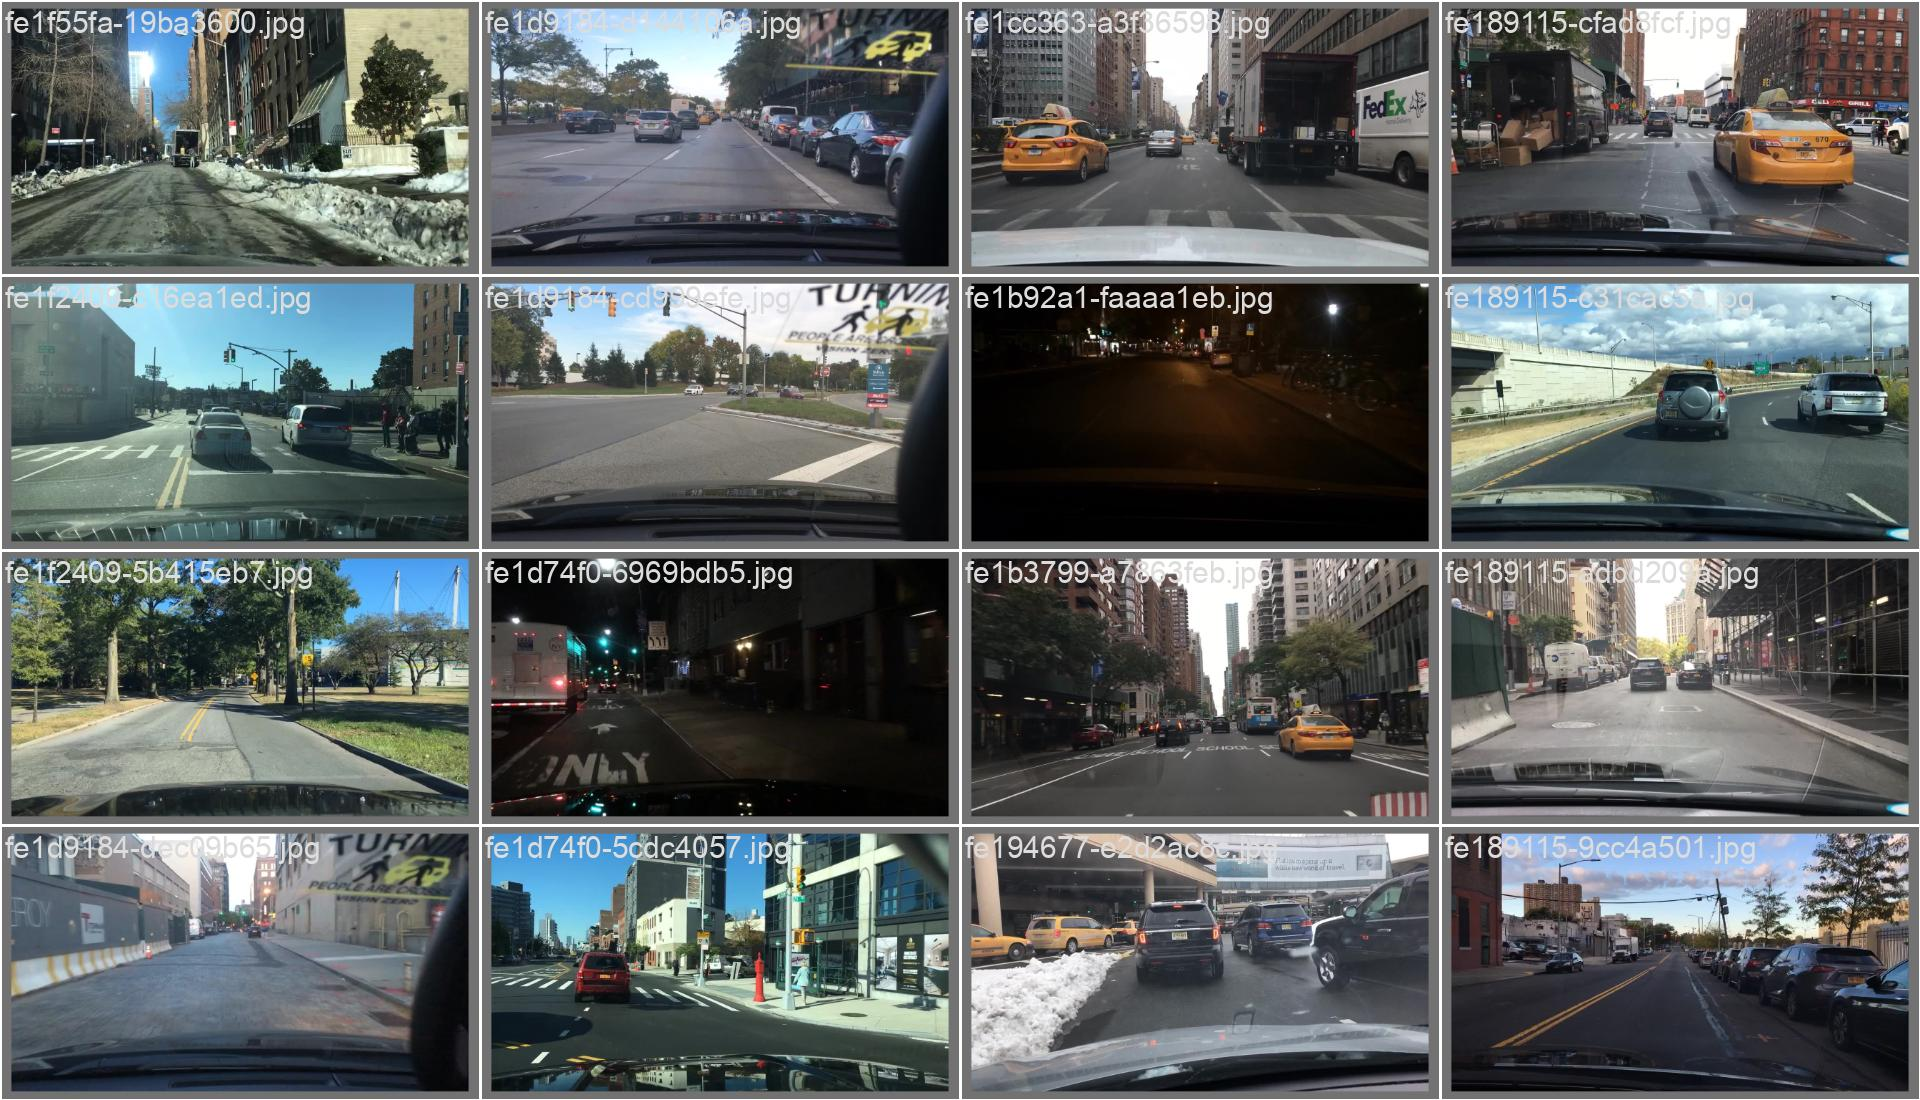

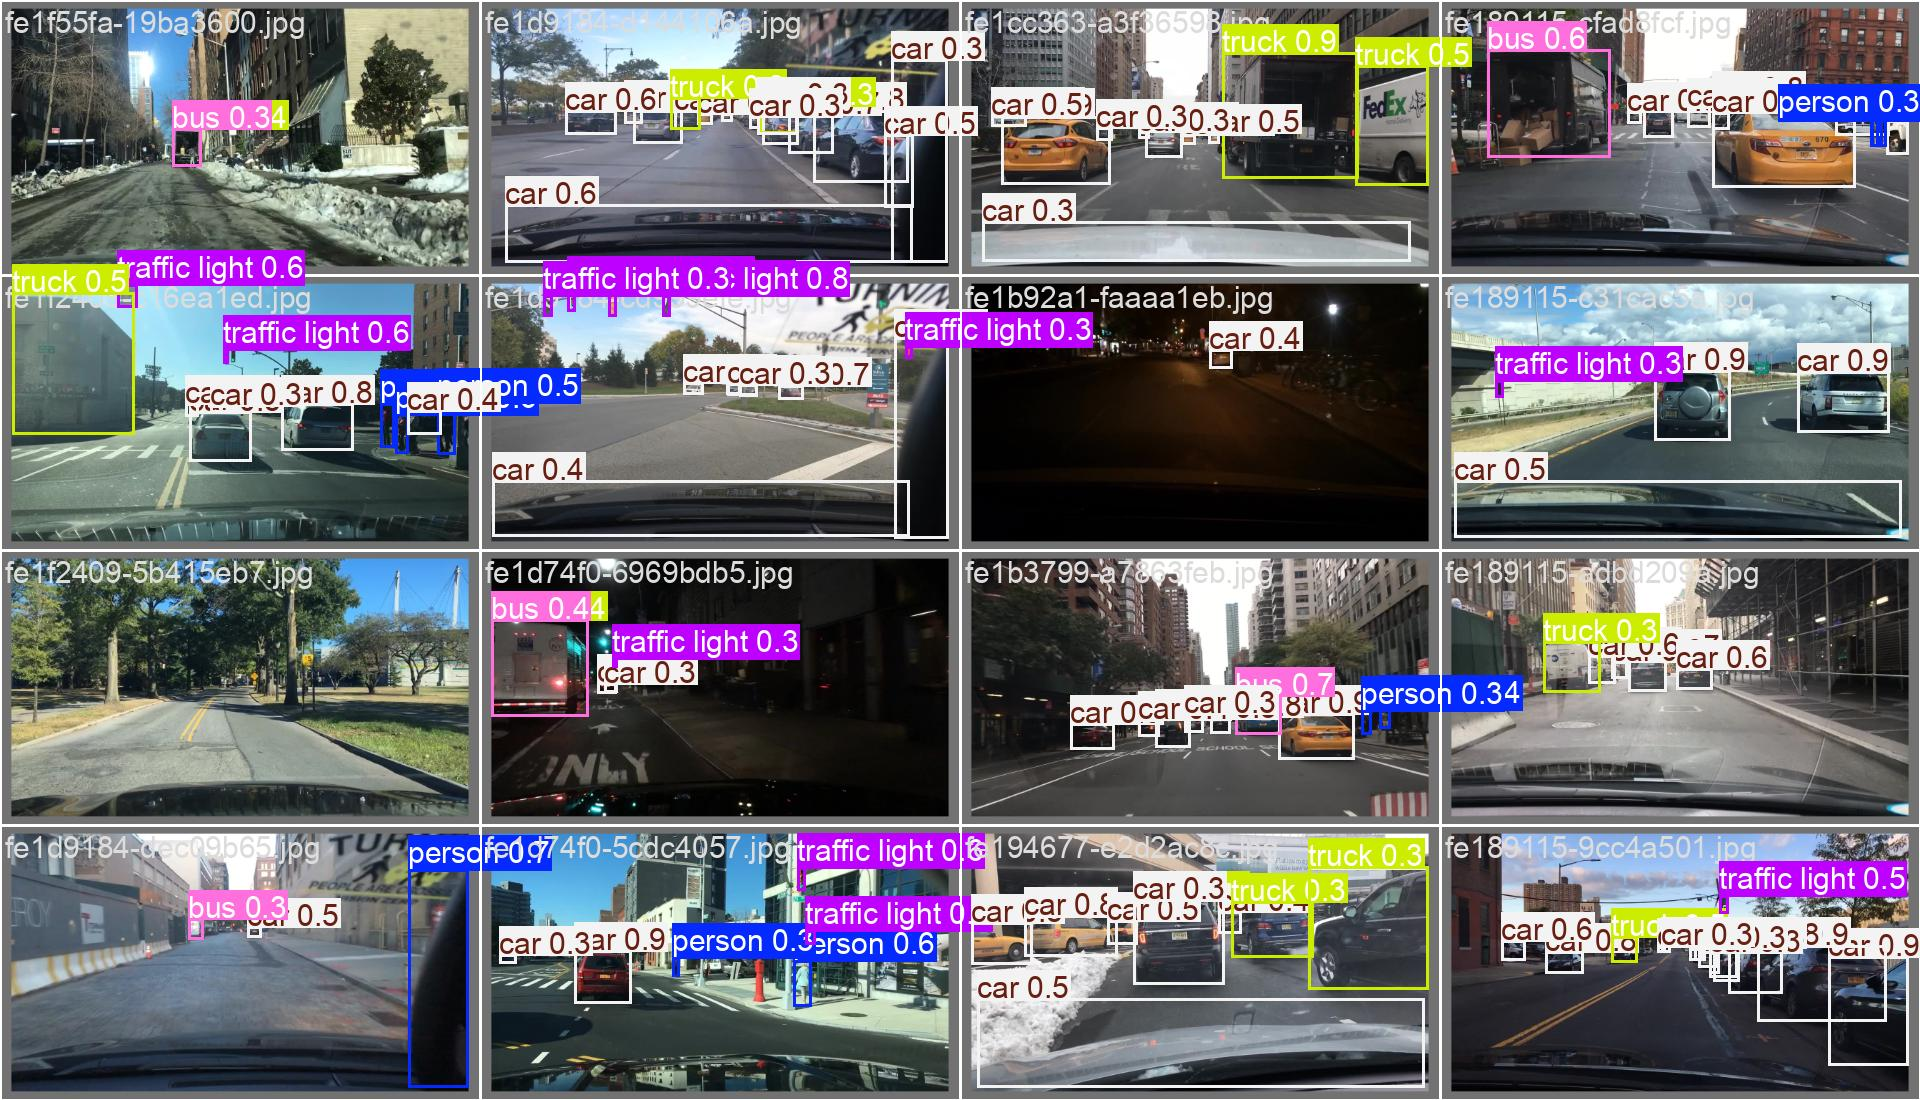

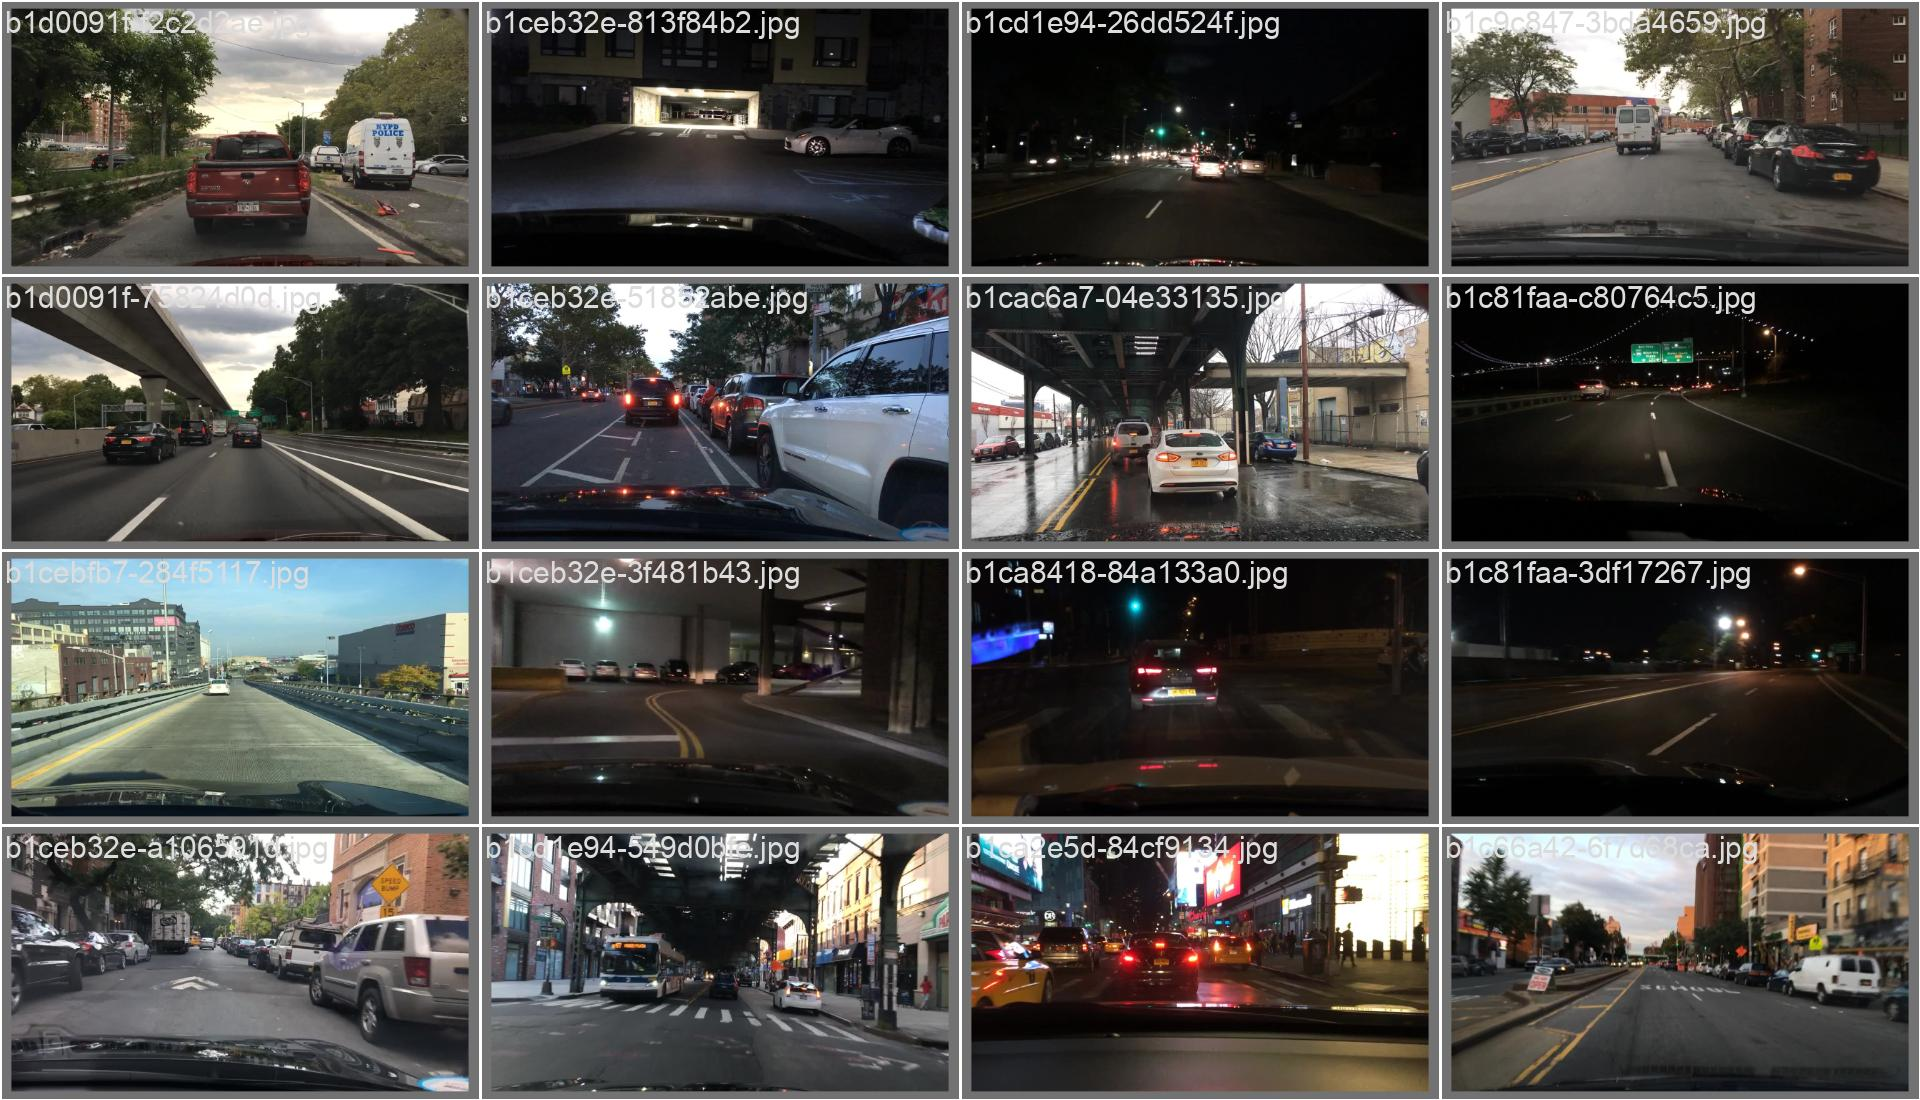

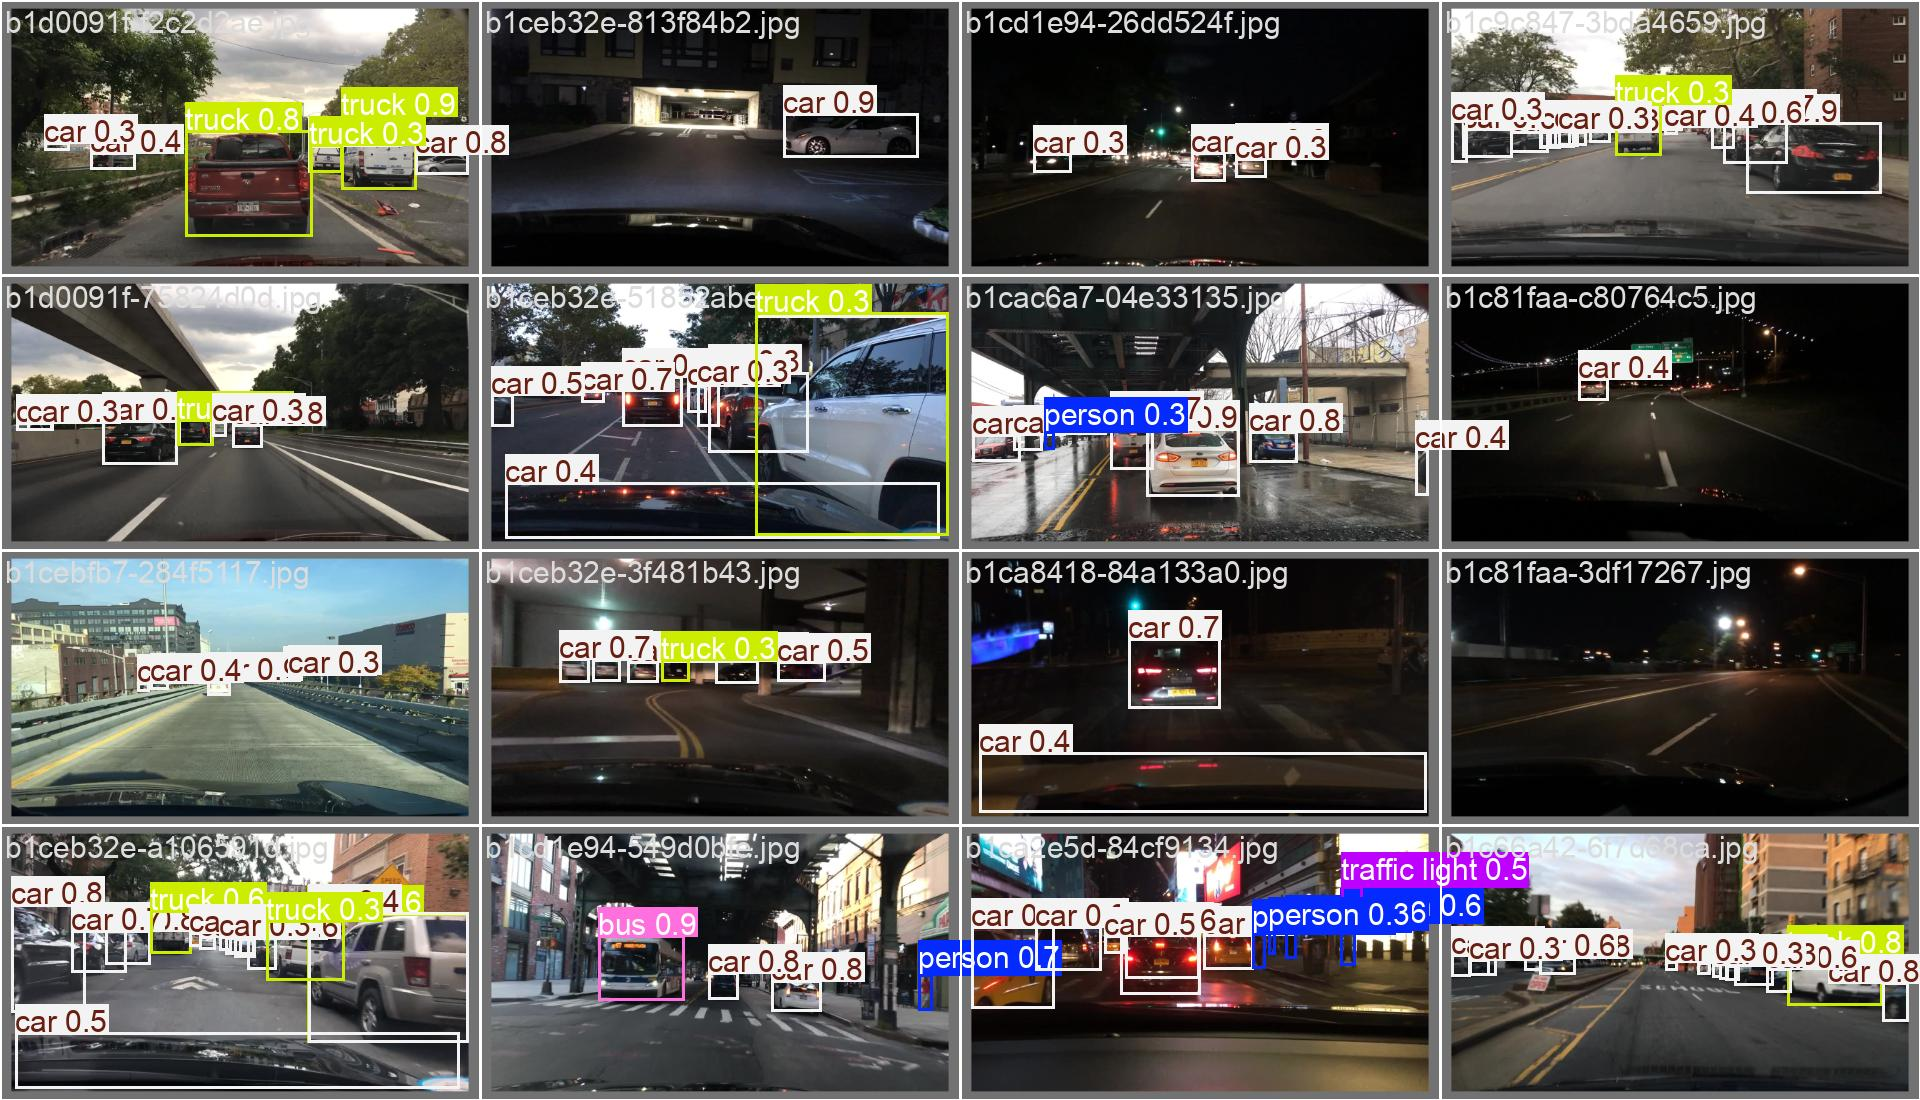

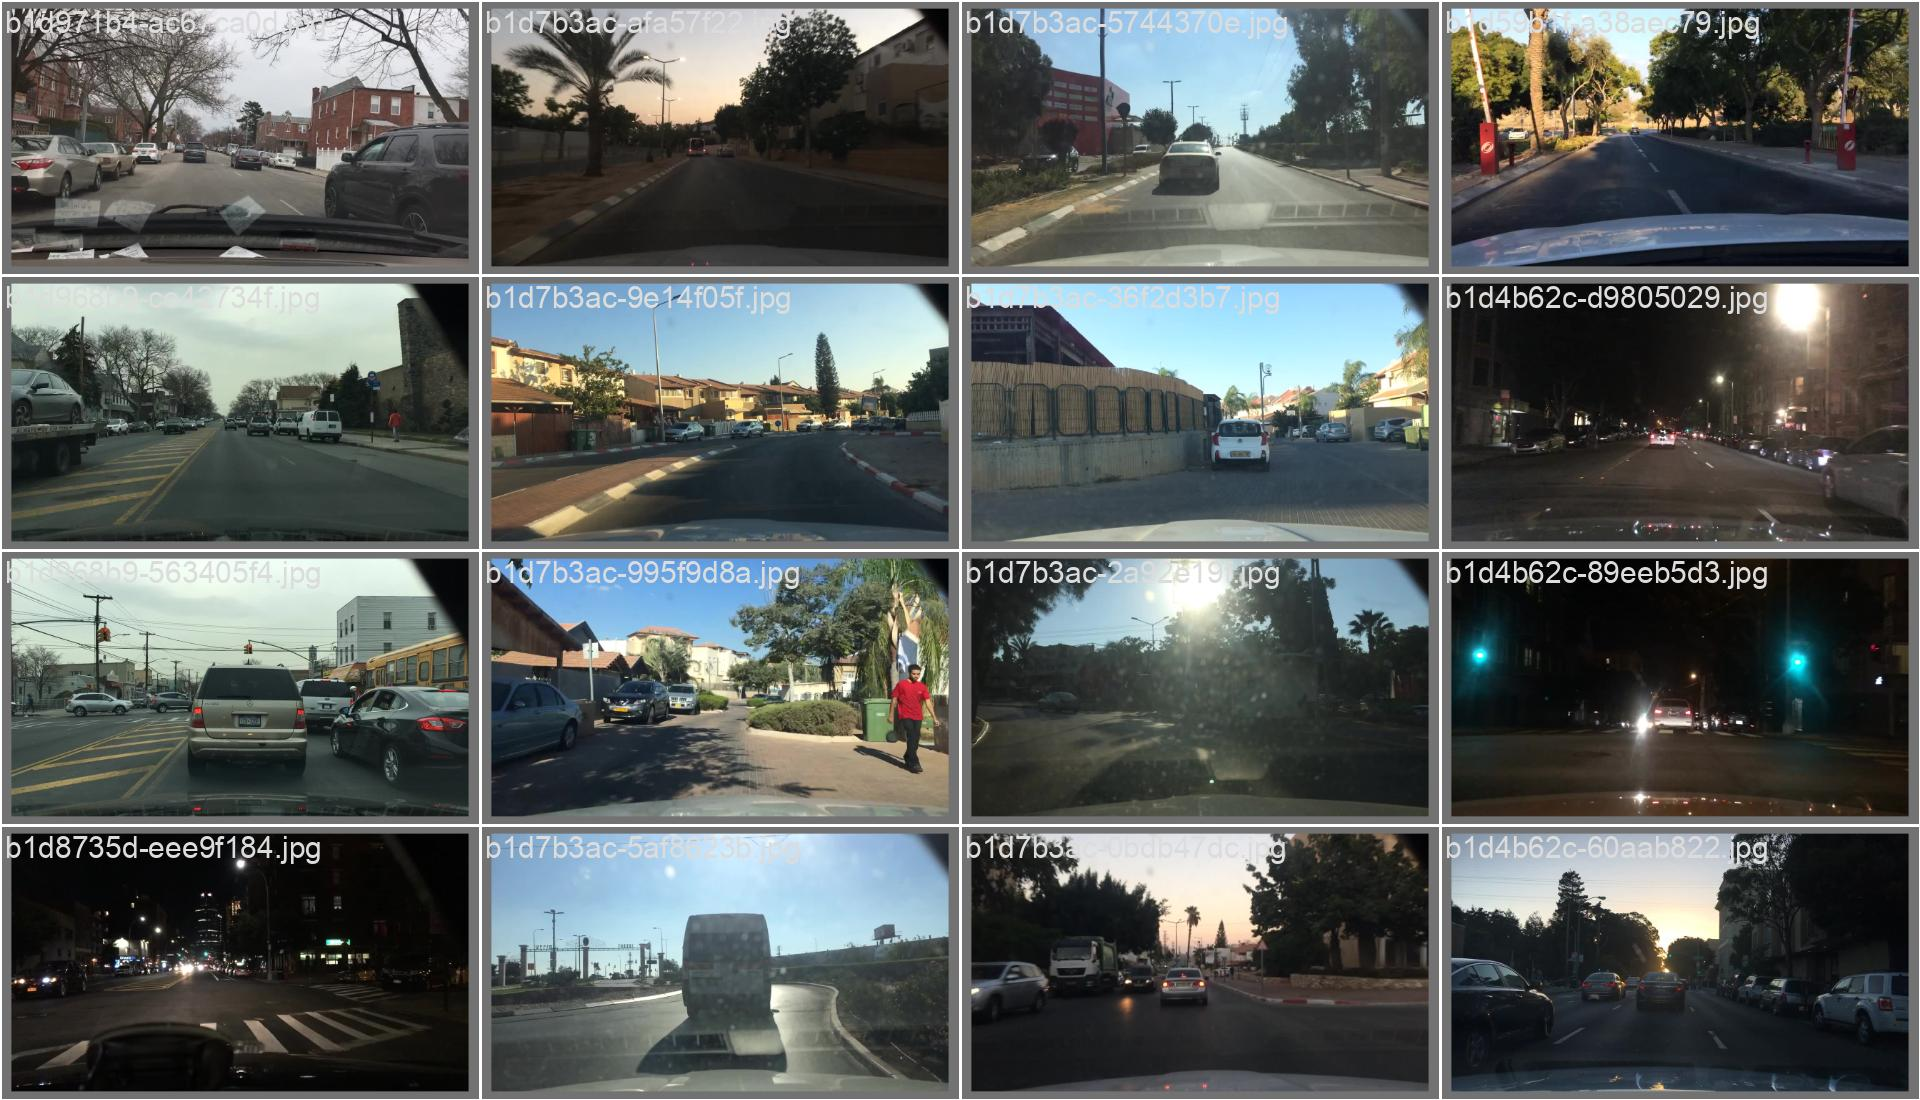

In [36]:
from IPython.display import Image, display
import glob

outputs = glob.glob("runs/detect/*/*.jpg")

for img in outputs[:5]:
    display(Image(filename=img))

## 7. Inference + distance annotation
Upload a test image OR use one from the val set.

In [38]:
# Pick sample images from BDD100K validation set

import glob
import os

val_imgs = glob.glob("/content/bdd100k_data/bdd100k/images/100k/val/*.jpg")[:5]

if not val_imgs:
    val_imgs = glob.glob("/content/bdd100k_data/bdd100k/images/100k/test/*.jpg")[:5]

print("Sample images:")
for img in val_imgs:
    print(img)

Sample images:


In [41]:
# Pick sample images from BDD100K automatically

import glob

val_imgs = glob.glob("/content/bdd100k_data/**/*.jpg", recursive=True)

print("Total images found:", len(val_imgs))

# Show first 5 images
for img in val_imgs[:5]:
    print(img)

TEST_IMG = val_imgs[0]
print("\nUsing:", TEST_IMG)

Total images found: 120000
/content/bdd100k_data/bdd100k_seg/bdd100k/seg/images/test/ea553cbb-00000000.jpg
/content/bdd100k_data/bdd100k_seg/bdd100k/seg/images/test/e9390b2c-27830687.jpg
/content/bdd100k_data/bdd100k_seg/bdd100k/seg/images/test/d2f3e8c3-f50eb10f.jpg
/content/bdd100k_data/bdd100k_seg/bdd100k/seg/images/test/c8add6c2-00000000.jpg
/content/bdd100k_data/bdd100k_seg/bdd100k/seg/images/test/f2b7f1db-00000000.jpg

Using: /content/bdd100k_data/bdd100k_seg/bdd100k/seg/images/test/ea553cbb-00000000.jpg


In [50]:
# Option B: upload your own test image
from google.colab import files
uploaded = files.upload()  # pick any .jpg/.png from your computer
TEST_IMG = list(uploaded.keys())[0]
print('Using:', TEST_IMG)

Saving istockphoto-120710941-612x612.jpg to istockphoto-120710941-612x612.jpg
Using: istockphoto-120710941-612x612.jpg


In [46]:
BEST_WEIGHTS = "yolov8n.pt"
print(BEST_WEIGHTS)

yolov8n.pt


Current TEST_IMG: istockphoto-120710941-612x612.jpg
Saved: runs/detect/final_output.jpg


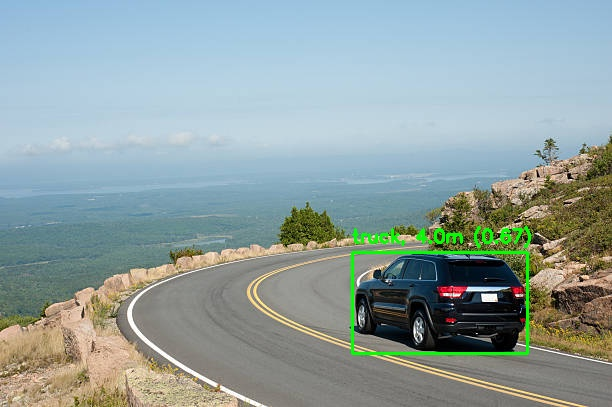

In [51]:
# FINAL SAFE IMAGE LOAD + DETECTION + DISTANCE CODE

import sys, cv2, time, os
sys.path.insert(0, "src")

from distance import DistanceEstimator
from ultralytics import YOLO
from IPython.display import Image, display

# -------------------------------------------------
# SET MODEL WEIGHTS
# -------------------------------------------------
BEST_WEIGHTS = "yolov8n.pt"   # safe default pretrained model

# -------------------------------------------------
# CHECK / SET IMAGE PATH
# -------------------------------------------------
print("Current TEST_IMG:", TEST_IMG)

if not os.path.exists(TEST_IMG):
    raise ValueError(f"Image file not found: {TEST_IMG}")

# -------------------------------------------------
# DISPLAY SETTINGS
# -------------------------------------------------
DISPLAY_NAMES = {
    "cone": "Cone",
    "barrier": "Barrier",
    "stop_sign": "Stop Sign",
    "stop sign": "Stop Sign",
    "traffic cone": "Cone"
}

COLORS = {
    "cone": (0,165,255),
    "barrier": (200,200,200),
    "stop_sign": (0,0,255),
    "stop sign": (0,0,255),
    "traffic cone": (0,165,255)
}

# -------------------------------------------------
# ANNOTATION FUNCTION
# -------------------------------------------------
def annotate(frame, model, est, conf=0.35):

    result = model.predict(
        frame,
        conf=conf,
        device="cpu",
        verbose=False
    )[0]

    names = result.names

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())

        cls_name = names[int(box.cls[0])]
        confv = float(box.conf[0])

        # Distance estimate
        dist = est.estimate(cls_name, y2 - y1)

        color = COLORS.get(cls_name, (0,255,0))
        label_name = DISPLAY_NAMES.get(cls_name, cls_name)

        if dist > 0:
            label = f"{label_name}, {dist:.1f}m ({confv:.2f})"
        else:
            label = f"{label_name} ({confv:.2f})"

        # Draw rectangle
        cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)

        # Draw text
        cv2.putText(
            frame,
            label,
            (x1, max(y1-10,20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    return frame

# -------------------------------------------------
# LOAD MODEL + DISTANCE MODULE
# -------------------------------------------------
model = YOLO(BEST_WEIGHTS)
est = DistanceEstimator("configs/camera.yaml")

# -------------------------------------------------
# LOAD IMAGE SAFELY
# -------------------------------------------------
img = cv2.imread(TEST_IMG)

if img is None:
    raise ValueError(f"Could not load image: {TEST_IMG}")

# -------------------------------------------------
# RUN ANNOTATION
# -------------------------------------------------
output = annotate(img.copy(), model, est)

# -------------------------------------------------
# SAVE OUTPUT
# -------------------------------------------------
os.makedirs("runs/detect", exist_ok=True)

out_path = "runs/detect/final_output.jpg"

cv2.imwrite(out_path, output)

print("Saved:", out_path)

# -------------------------------------------------
# SHOW OUTPUT
# -------------------------------------------------
display(Image(filename=out_path))

Saved: runs/detect/demo/demo_0.jpg


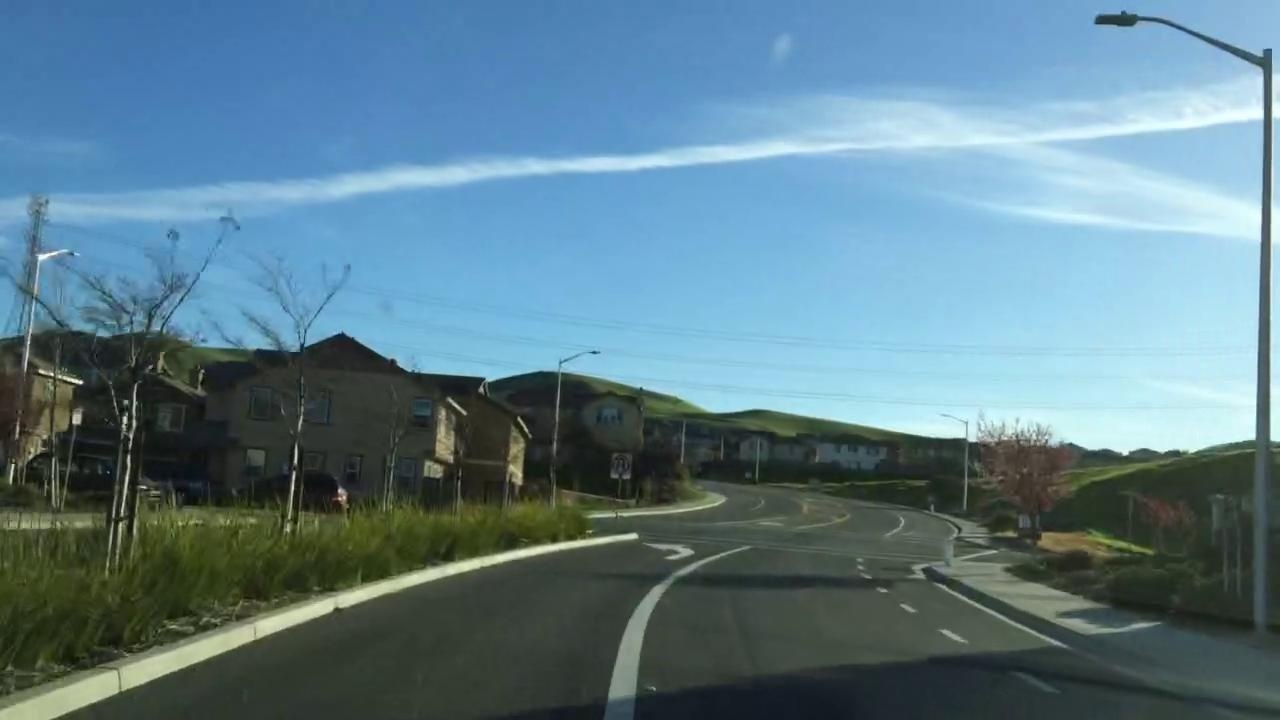

Saved: runs/detect/demo/demo_1.jpg


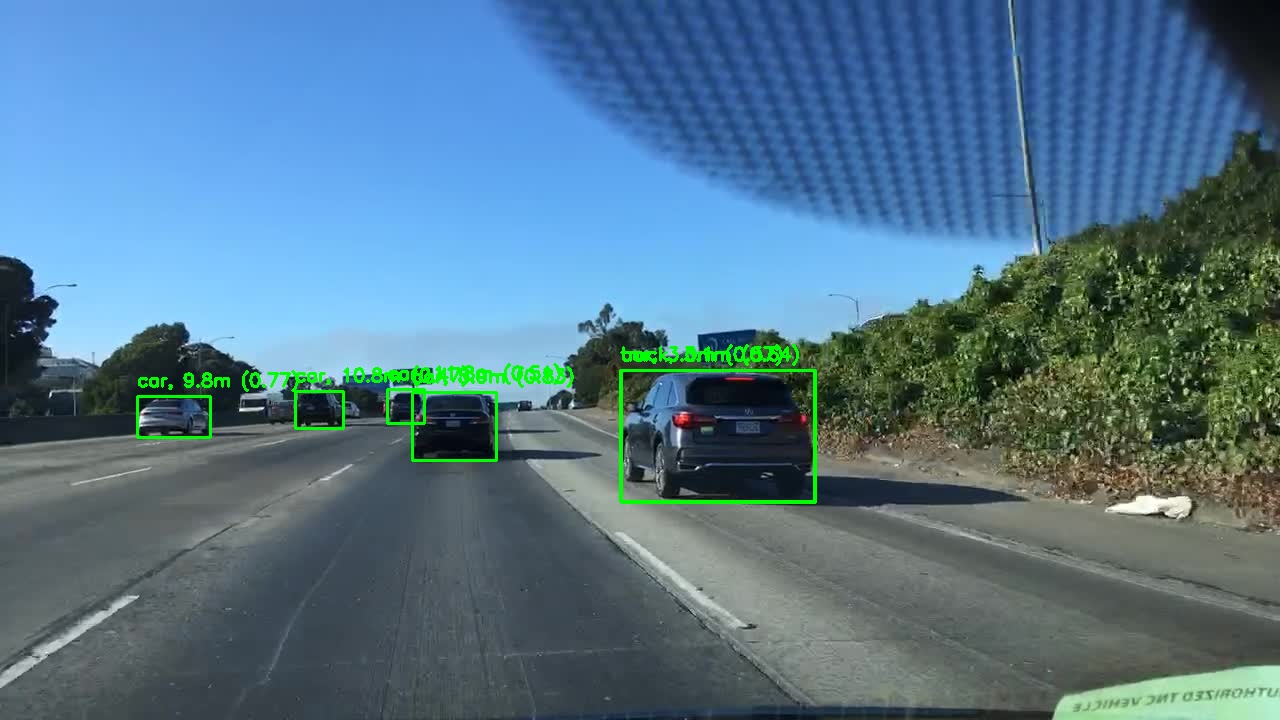

Saved: runs/detect/demo/demo_2.jpg


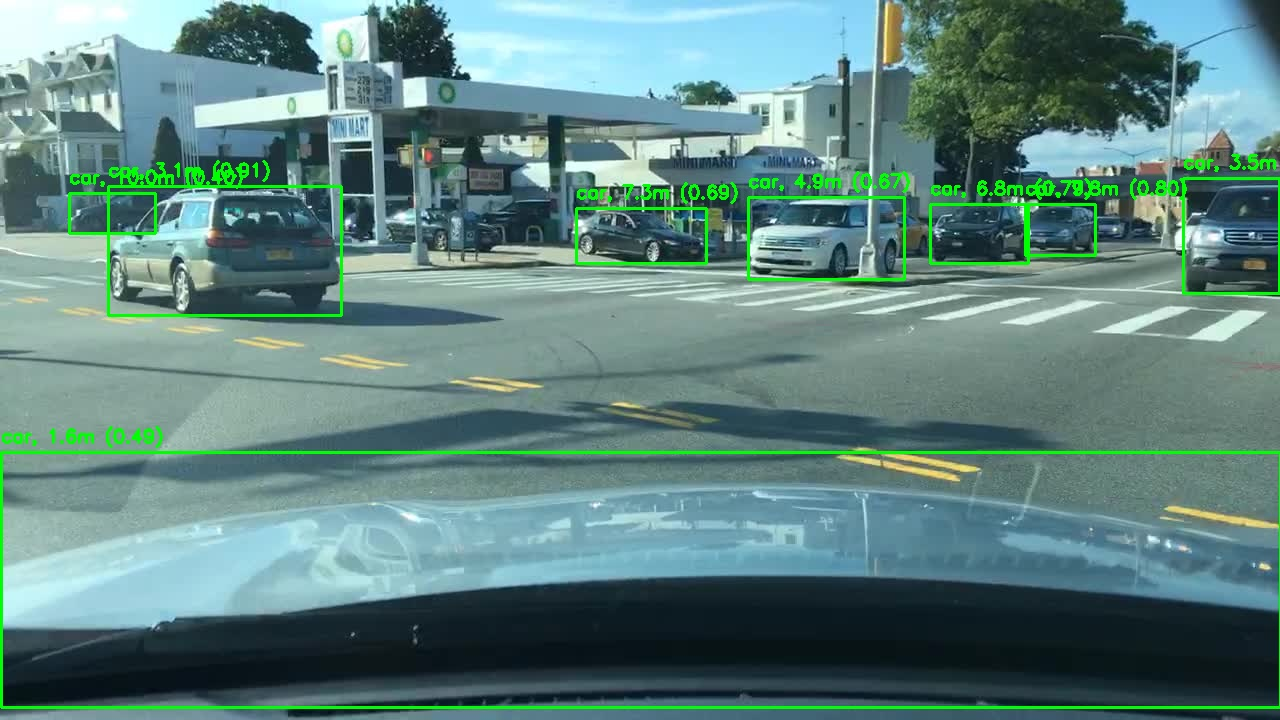

Saved: runs/detect/demo/demo_3.jpg


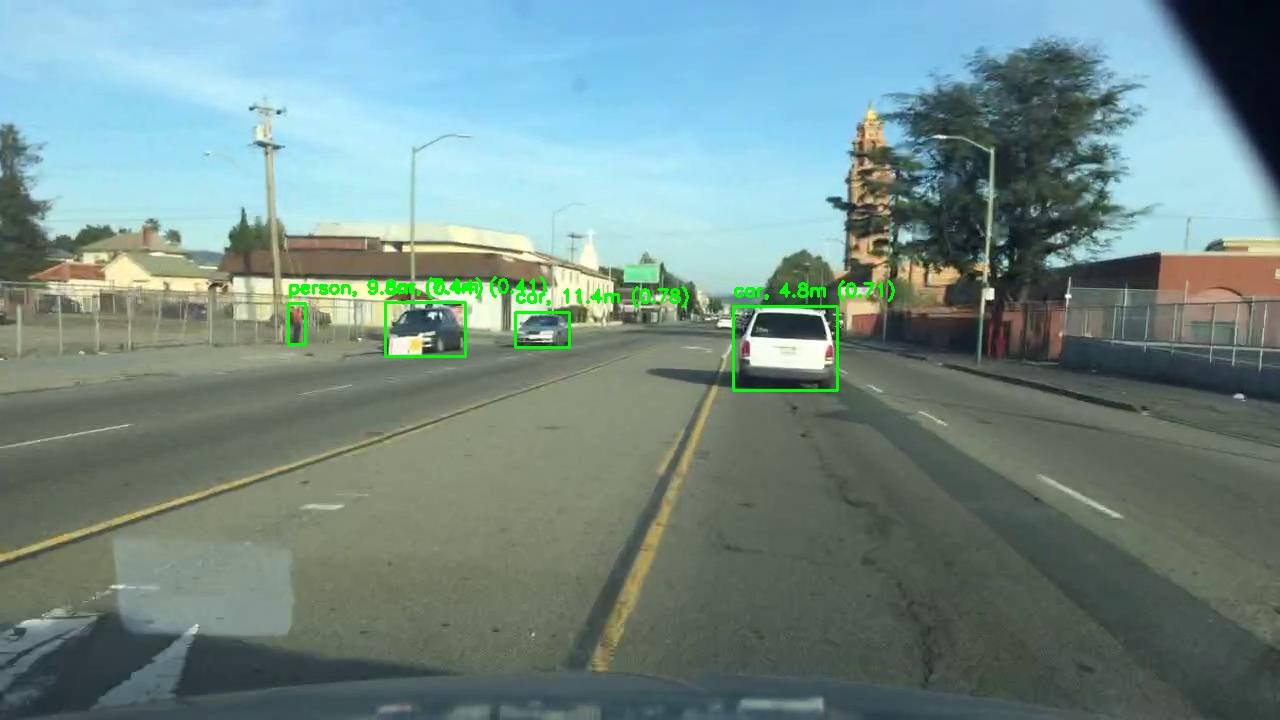

Saved: runs/detect/demo/demo_4.jpg


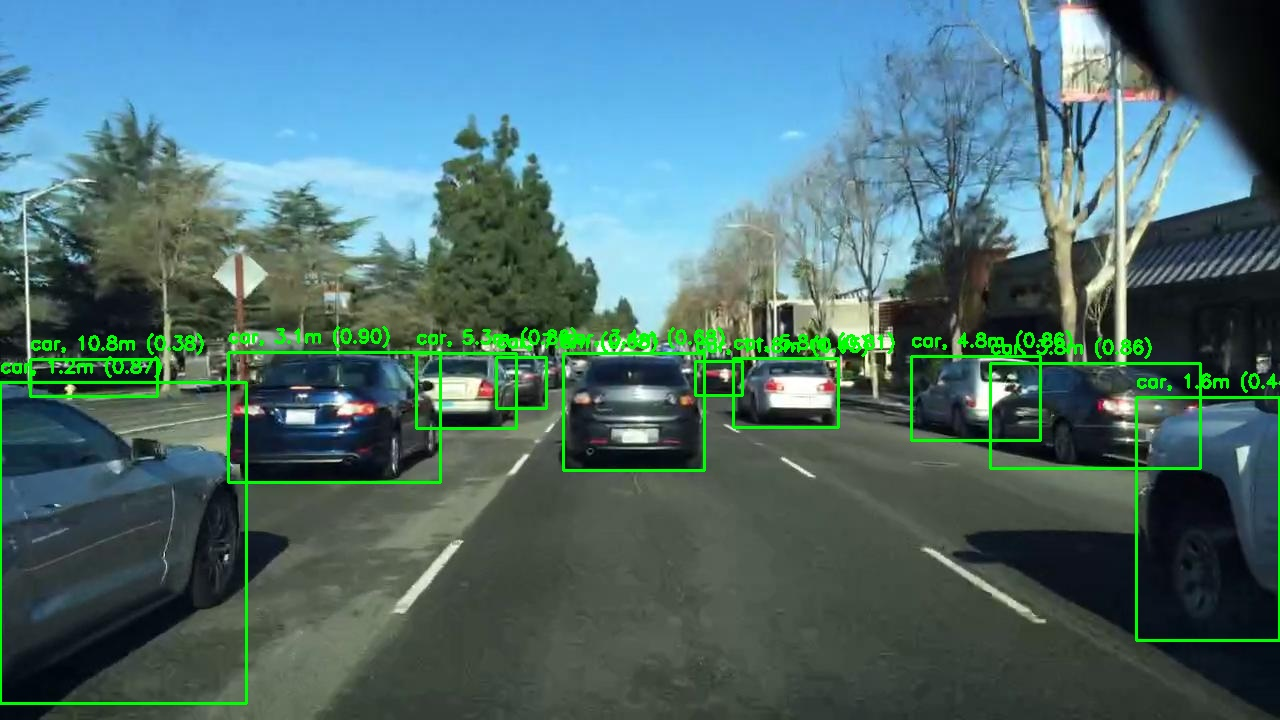

Saved: runs/detect/demo/demo_5.jpg


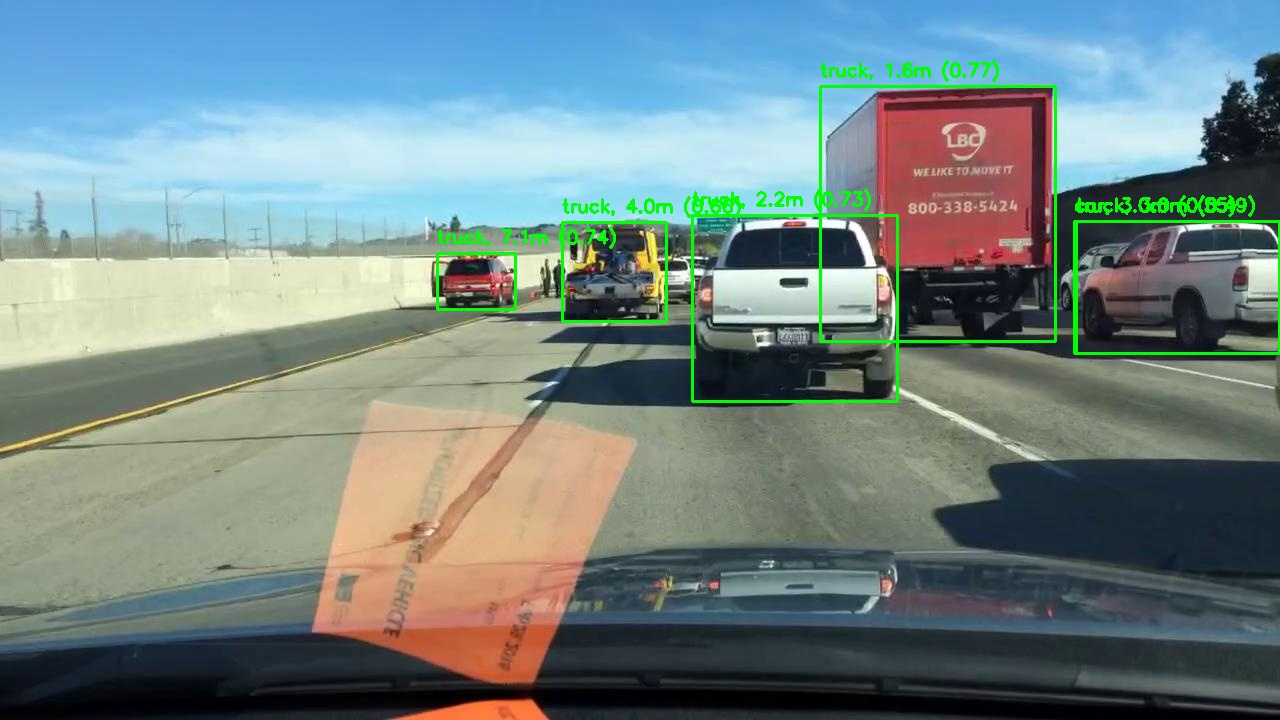

In [52]:
# Batch annotate images for demo gallery

import glob, os
from IPython.display import Image, display

demo_imgs = glob.glob("/content/bdd100k_data/**/*.jpg", recursive=True)[:6]

os.makedirs("runs/detect/demo", exist_ok=True)

for i, p in enumerate(demo_imgs):
    img = cv2.imread(p)

    if img is None:
        continue

    out = annotate(img.copy(), model, est)

    save_path = f"runs/detect/demo/demo_{i}.jpg"
    cv2.imwrite(save_path, out)

    print("Saved:", save_path)
    display(Image(filename=save_path))

## 8. Calibrate focal length (recommended)
Distances above use default `focal_px=800`. For real numbers, photograph any known-size object at known distance.

Example: stop sign 0.75m tall, you stood 3m away, bbox in image was 188px tall:

In [53]:
# Plug in your measurements:
BBOX_H_PX = 188
DISTANCE_M = 3.0
REAL_H_M = 0.75

focal = (BBOX_H_PX * DISTANCE_M) / REAL_H_M
print(f'Calibrated focal_px = {focal:.1f}')
print(f'Update configs/camera.yaml with: focal_px: {int(focal)}')

Calibrated focal_px = 752.0
Update configs/camera.yaml with: focal_px: 752


## 9. Optimization — ONNX export + INT8 quantization

In [54]:
# Export to ONNX FP32
model = YOLO(BEST_WEIGHTS)
onnx_path = model.export(format='onnx', imgsz=640, opset=12, simplify=True)
print('ONNX FP32:', onnx_path)

import shutil, os
os.makedirs('runs/optimize', exist_ok=True)
shutil.copy(onnx_path, 'runs/optimize/model_fp32.onnx')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 3.4s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (4.1s)
Results saved to /content/drive/MyDrive/eric_robotics_assignment
Predict:         yolo predict task=detect model=yolov8n.onnx imgsz=640 
Validate:        yolo val task=detect model=yolov8n.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app
ONNX FP32: yolov8n.onnx


'runs/optimize/model_fp32.onnx'

In [55]:
# Dynamic INT8 quantization
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input='runs/optimize/model_fp32.onnx',
    model_output='runs/optimize/model_int8.onnx',
    weight_type=QuantType.QUInt8,
)

fp32_size = os.path.getsize('runs/optimize/model_fp32.onnx') / 1e6
int8_size = os.path.getsize('runs/optimize/model_int8.onnx') / 1e6
print(f'FP32 ONNX: {fp32_size:.2f} MB')
print(f'INT8 ONNX: {int8_size:.2f} MB')
print(f'Compression: {fp32_size/int8_size:.2f}x smaller')

FP32 ONNX: 12.85 MB
INT8 ONNX: 3.50 MB
Compression: 3.67x smaller


## 10. Benchmark — FPS comparison across variants

In [56]:
import time, numpy as np, cv2, os
import onnxruntime as ort
from ultralytics import YOLO
import pandas as pd

BENCH_IMG = TEST_IMG
RUNS = 30
WARMUP = 5

results = []

# Load image
img = cv2.imread(BENCH_IMG)

# 1. PyTorch CPU
m = YOLO(BEST_WEIGHTS)

for _ in range(WARMUP):
    m.predict(img, device="cpu", verbose=False)

t = time.time()
for _ in range(RUNS):
    m.predict(img, device="cpu", verbose=False)

fps = RUNS / (time.time() - t)

results.append({
    "name": "PyTorch FP32 (CPU)",
    "fps": round(fps,2),
    "latency_ms": round(1000/fps,2),
    "size_mb": round(os.path.getsize(BEST_WEIGHTS)/1e6,2)
})

# preprocess for ONNX
def prep(p, size=640):
    im = cv2.imread(p)
    im = cv2.resize(im, (640,640))
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    return im.transpose(2,0,1)[None,...]

x = prep(BENCH_IMG)

# 2. ONNX FP32
sess = ort.InferenceSession(
    "runs/optimize/model_fp32.onnx",
    providers=["CPUExecutionProvider"]
)

iname = sess.get_inputs()[0].name

for _ in range(WARMUP):
    sess.run(None,{iname:x})

t = time.time()
for _ in range(RUNS):
    sess.run(None,{iname:x})

fps = RUNS/(time.time()-t)

results.append({
    "name":"ONNX FP32 (CPU)",
    "fps":round(fps,2),
    "latency_ms":round(1000/fps,2),
    "size_mb":round(fp32_size,2)
})

# 3. ONNX INT8
sess = ort.InferenceSession(
    "runs/optimize/model_int8.onnx",
    providers=["CPUExecutionProvider"]
)

iname = sess.get_inputs()[0].name

for _ in range(WARMUP):
    sess.run(None,{iname:x})

t=time.time()
for _ in range(RUNS):
    sess.run(None,{iname:x})

fps = RUNS/(time.time()-t)

results.append({
    "name":"ONNX INT8 (CPU)",
    "fps":round(fps,2),
    "latency_ms":round(1000/fps,2),
    "size_mb":round(int8_size,2)
})

df = pd.DataFrame(results)
print(df.to_string(index=False))

              name  fps  latency_ms  size_mb
PyTorch FP32 (CPU) 5.46      183.27     6.55
   ONNX FP32 (CPU) 5.86      170.72    12.85
   ONNX INT8 (CPU) 3.85      259.92     3.50


In [57]:
# Show benchmark as markdown table for README
print('| Variant | Size (MB) | FPS | Latency (ms) |')
print('|---|---|---|---|')
for r in results:
    print(f"| {r['name']} | {r['size_mb']} | {r['fps']} | {r['latency_ms']} |")

| Variant | Size (MB) | FPS | Latency (ms) |
|---|---|---|---|
| PyTorch FP32 (CPU) | 6.55 | 5.46 | 183.27 |
| ONNX FP32 (CPU) | 12.85 | 5.86 | 170.72 |
| ONNX INT8 (CPU) | 3.5 | 3.85 | 259.92 |


## 11. Before vs After comparison

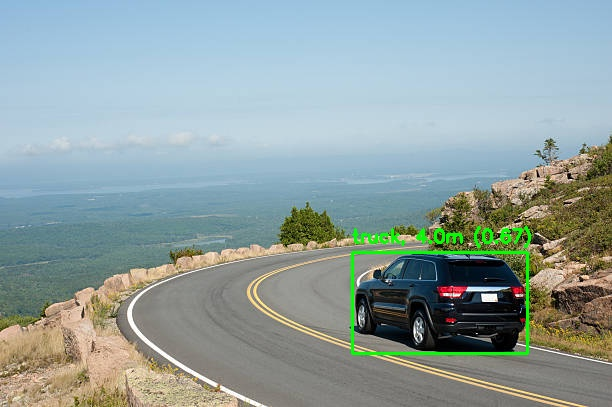


Size comparison:
  PyTorch .pt:    6.55 MB
  ONNX FP32:      12.85 MB
  ONNX INT8:      3.50 MB ← deployment-ready for edge


In [58]:
# Save FP32 PyTorch detection vs INT8 ONNX detection side by side
# (For ONNX, we'd need separate post-processing — for the assignment,
# showing the same model's output + benchmark numbers is sufficient.)

model_pt = YOLO(BEST_WEIGHTS)
img = cv2.imread(TEST_IMG)
out = annotate(img.copy(), model_pt, est)
cv2.imwrite('runs/detect/before_optim.jpg', out)
display(Image('runs/detect/before_optim.jpg'))

print('\nSize comparison:')
print(f'  PyTorch .pt:    {os.path.getsize(BEST_WEIGHTS)/1e6:.2f} MB')
print(f'  ONNX FP32:      {fp32_size:.2f} MB')
print(f'  ONNX INT8:      {int8_size:.2f} MB ← deployment-ready for edge')

## 12. Download all outputs to your PC
Zip everything important and download — push these to your repo.

In [59]:
# Bundle deliverables
!mkdir -p deliverables
!cp runs/train/exp/weights/best.pt deliverables/best.pt
!cp runs/optimize/model_fp32.onnx deliverables/
!cp runs/optimize/model_int8.onnx deliverables/
!cp runs/train/exp/results.png deliverables/training_curves.png 2>/dev/null || true
!cp runs/train/exp/confusion_matrix.png deliverables/ 2>/dev/null || true
!cp runs/benchmark/results.csv deliverables/
!cp -r runs/detect/demo deliverables/demo_images 2>/dev/null || true
!cp runs/detect/annotated.jpg deliverables/ 2>/dev/null || true

!zip -r deliverables.zip deliverables/
!ls -lh deliverables.zip

cp: cannot stat 'runs/train/exp/weights/best.pt': No such file or directory
cp: cannot stat 'runs/benchmark/results.csv': No such file or directory
  adding: deliverables/ (stored 0%)
  adding: deliverables/model_fp32.onnx (deflated 14%)
  adding: deliverables/model_int8.onnx (deflated 37%)
  adding: deliverables/demo_images/ (stored 0%)
  adding: deliverables/demo_images/demo_0.jpg (deflated 7%)
  adding: deliverables/demo_images/demo_1.jpg (deflated 9%)
  adding: deliverables/demo_images/demo_2.jpg (deflated 10%)
  adding: deliverables/demo_images/demo_3.jpg (deflated 5%)
  adding: deliverables/demo_images/demo_4.jpg (deflated 5%)
  adding: deliverables/demo_images/demo_5.jpg (deflated 6%)
-rw------- 1 root root 14M Apr 25 11:14 deliverables.zip


In [60]:
# Download to your PC
from google.colab import files
files.download('deliverables.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>